In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import random
from pathlib import Path

from torchvision import transforms

print("PyTorch version:", torch.__version__)

PyTorch version: 2.6.0+cu124


In [2]:
import h5py

In [3]:
#REPRODUCIBILITY

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
# import datasets

import kagglehub
path = kagglehub.dataset_download(
    "awsaf49/brats2020-training-data",
    output_dir = "/mnt/volume/datasets"
)

print("Path to dataset files:", path)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


100%|██████████████████████████████████████| 6.76G/6.76G [03:12<00:00, 37.8MB/s]

Extracting files...


Path to dataset files: /mnt/volume/datasets


In [6]:
#import metadata
import pandas as pd

In [8]:
metadata = pd.read_csv('/mnt/volume/DL_Training/datasets/BraTS20_Training_Metadata.csv')

In [9]:
metadata.head()

,slice_path,target,volume,slice,label0_pxl_cnt,label1_pxl_cnt,label2_pxl_cnt,background_ratio
0,../input/brats2020-training-data/BraTS2020_tra...,0,41,0,0,0,0,1.0
1,../input/brats2020-training-data/BraTS2020_tra...,0,41,1,0,0,0,1.0
2,../input/brats2020-training-data/BraTS2020_tra...,0,41,2,0,0,0,1.0
3,../input/brats2020-training-data/BraTS2020_tra...,0,41,3,0,0,0,1.0
4,../input/brats2020-training-data/BraTS2020_tra...,0,41,4,0,0,0,1.0


In [15]:
metadata['slice_path'][0]
#get the base directory
ARCHIVE_DIR = '/mnt/volume/DL_Training/datasets/BraTS2020_training_data/content/data/'
#get the file name
FILE_NAMES = os.listdir(ARCHIVE_DIR)

In [16]:
FILE_NAMES

['volume_260_slice_97.h5',
 'volume_32_slice_40.h5',
 'volume_262_slice_41.h5',
 'volume_161_slice_26.h5',
 'volume_45_slice_108.h5',
 'volume_94_slice_12.h5',
 'volume_310_slice_135.h5',
 'volume_314_slice_42.h5',
 'volume_337_slice_95.h5',
 'volume_359_slice_121.h5',
 'volume_293_slice_7.h5',
 'volume_202_slice_72.h5',
 'volume_306_slice_68.h5',
 'volume_205_slice_8.h5',
 'volume_132_slice_128.h5',
 'volume_342_slice_53.h5',
 'volume_56_slice_56.h5',
 'volume_247_slice_82.h5',
 'volume_198_slice_23.h5',
 'volume_167_slice_141.h5',
 'volume_145_slice_36.h5',
 'volume_204_slice_134.h5',
 'volume_42_slice_4.h5',
 'volume_158_slice_123.h5',
 'volume_68_slice_7.h5',
 'volume_28_slice_49.h5',
 'volume_300_slice_124.h5',
 'volume_180_slice_5.h5',
 'volume_125_slice_149.h5',
 'volume_242_slice_127.h5',
 'volume_360_slice_140.h5',
 'volume_108_slice_23.h5',
 'volume_163_slice_33.h5',
 'volume_14_slice_67.h5',
 'volume_281_slice_133.h5',
 'volume_60_slice_55.h5',
 'volume_363_slice_80.h5',
 'v

In [17]:
len(FILE_NAMES)

57198

In [255]:
RANDOM_SELECT = random.randint(0,len(FILE_NAMES))
print(RANDOM_SELECT)

5697


/mnt/volume/DL_Training/datasets/BraTS2020_training_data/content/data/volume_260_slice_97.h5
<KeysViewHDF5 ['image', 'mask']>
<HDF5 dataset "image": shape (240, 240, 4), type "<f8">
<HDF5 dataset "mask": shape (240, 240, 3), type "|u1">
[[-0.54461307 -0.54461307 -0.54461307 ... -0.54461307 -0.54461307
  -0.54461307]
 [-0.54461307 -0.54461307 -0.54461307 ... -0.54461307 -0.54461307
  -0.54461307]
 [-0.54461307 -0.54461307 -0.54461307 ... -0.54461307 -0.54461307
  -0.54461307]
 ...
 [-0.54461307 -0.54461307 -0.54461307 ... -0.54461307 -0.54461307
  -0.54461307]
 [-0.54461307 -0.54461307 -0.54461307 ... -0.54461307 -0.54461307
  -0.54461307]
 [-0.54461307 -0.54461307 -0.54461307 ... -0.54461307 -0.54461307
  -0.54461307]]


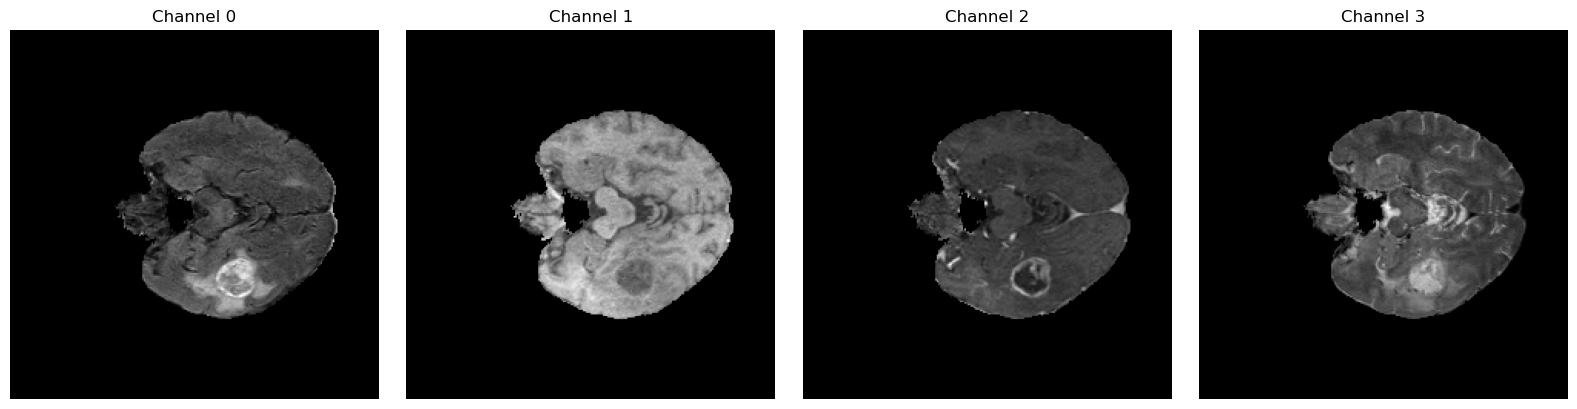

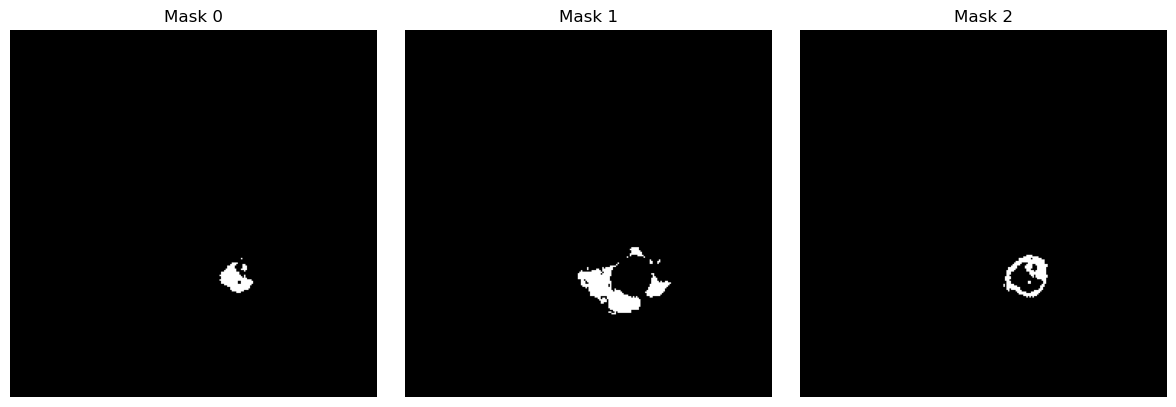

In [250]:
RANDOM_SELECT = random.randint(0,len(FILE_NAMES))

#test file loading
print(ARCHIVE_DIR + FILE_NAMES[0])

TEST_FILE = h5py.File(ARCHIVE_DIR+FILE_NAMES[RANDOM_SELECT], 'r')

print(TEST_FILE.keys())
print(TEST_FILE['image'])
print(TEST_FILE['mask'])

#View test file
img = (TEST_FILE['image'])
mask = (TEST_FILE['mask'])

#
print(img[:, :, 1])

#MODALITIES = ['T1','T1ice', 'T2', 'FLAIR']
MODALITIES = [0,1,2,3]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(img[:, :, i], cmap='gray')
    axes[i].set_title(f'Channel {MODALITIES[i]}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    axes[i].imshow(mask[:, :, i], cmap='gray')
    axes[i].set_title(f'Mask {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()


In [28]:
print(img.shape)
print(mask.shape)

(240, 240, 4)
(240, 240, 3)


In [29]:
'volume_54_slice_149.h5'.split('.')[-1]

'h5'

In [285]:
class BratsSegmentationDataset(Dataset):
    def __init__(self, img_size = (240,240)):
        self.root_dir = FILE_NAMES
        self.img_size = img_size
        self.files = []

        for file in FILE_NAMES:
            if not file.endswith('.h5'):
                continue
                
            file_path = ARCHIVE_DIR + file

            with h5py.File(file_path, "r") as f:
                img = f["image"][:]
                mask = f["mask"][:]
                #print(img.shape[:2])

            if img.shape[:2] != (240, 240):
                continue
            if mask.shape[:2] != (240, 240):
                continue
            if img.shape[2] != 4:
                continue
            if mask.shape[2] != 3:
                continue
            #clean up masks 
            tumor_mask = mask.sum(axis=2)
            #print(tumor_mask.sum())
            if tumor_mask.sum() == 0:
                continue

            #append only clean files with a mask
            self.files.append(file_path)
        print(f"Valid non-empty samples: {len(self.files)}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        Image_path = self.files[idx]
        #print(Image_path)
        IMG_FILE = h5py.File(Image_path, 'r')

        img = IMG_FILE['image']
        mask = IMG_FILE['mask'][:]
        #print(mask)

        #return only FLAIR
        img = torch.tensor(img[:, :, 3], dtype=torch.float32).unsqueeze(0)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8) #normalize

        tumor_mask = mask.sum(axis=2)
        mask = torch.tensor(tumor_mask, dtype=torch.float32).unsqueeze(0)
    
        return {
            'image': img,
            'mask': mask
        }


In [286]:
BRAT_DATASET = BratsSegmentationDataset()
print('Number of image-mask pair: ', len(BRAT_DATASET))

Valid non-empty samples: 24422
Number of image-mask pair:  24422


In [287]:
RANDOM_SELECT

5697

In [288]:
BRAT_DATASET[RANDOM_SELECT]['image'].dtype

torch.float32

In [289]:
BRAT_DATASET[RANDOM_SELECT]['mask']

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [290]:
#generate 3 random figures
RANDOM_COLLECTION = []
for i in range(3):
    RANDOM_COLLECTION.append(random.randint(0,len(BRAT_DATASET)))

print(RANDOM_COLLECTION)

[7623, 16559, 19726]


(240, 240, 4) (240, 240, 3)
(240, 240, 4) (240, 240, 3)
(240, 240, 4) (240, 240, 3)


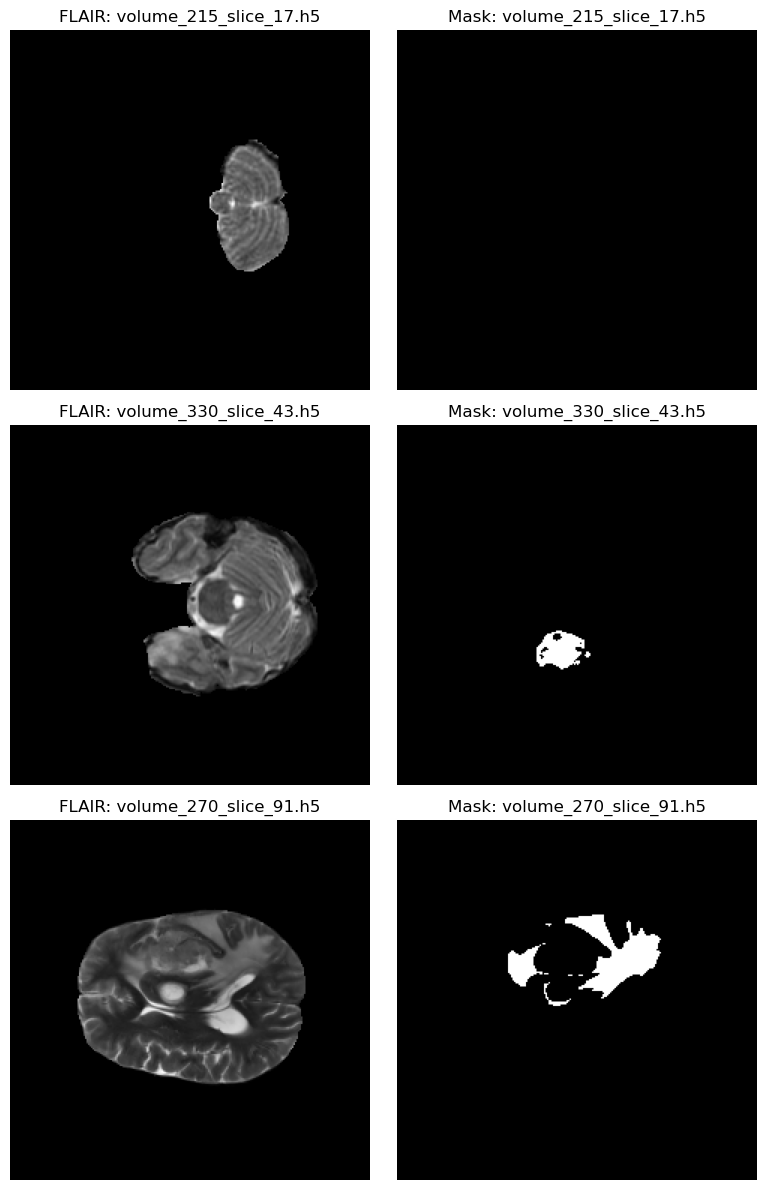

In [291]:
fig, axes = plt.subplots(len(RANDOM_COLLECTION), 2, figsize=(8,4 * len(RANDOM_COLLECTION)))
# Handle case with only one sample
if len(RANDOM_COLLECTION) == 1:
    axes = [axes]
for i, f_samp in enumerate(RANDOM_COLLECTION):
    with h5py.File(ARCHIVE_DIR + FILE_NAMES[f_samp], 'r') as f:
        img = f['image'][:]
        mask = f['mask'][:]
        print(img.shape, mask.shape)
    # FLAIR image
    axes[i][0].imshow(img[:, :, 3], cmap='gray')
    axes[i][0].set_title(f'FLAIR: {FILE_NAMES[f_samp]}')
    axes[i][0].axis('off')
    # Mask
    axes[i][1].imshow(mask[:, :, 1], cmap='gray')
    axes[i][1].set_title(f'Mask: {FILE_NAMES[f_samp]}')
    axes[i][1].axis('off')
plt.tight_layout()
plt.show()

In [292]:
# train/test split

In [293]:
total_size = len(BRAT_DATASET)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    BRAT_DATASET,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 17095
Val size: 3663
Test size: 3664


In [294]:
batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
images = batch["image"]
masks = batch["mask"]

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)

Image batch shape: torch.Size([8, 1, 240, 240])
Mask batch shape: torch.Size([8, 1, 240, 240])


In [295]:
# let's build the unet step by step

In [296]:
#Double Conv
class DoubleConv(nn.Module):
    def __init__ (self, in_channel, out_channel):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channel, out_channel, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

#Down
class Down(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channel, out_channel),
        )
    def forward(self, x):
        x = self.down(x)
        return x

#Up
class Up(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channel, in_channel//2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channel, out_channel)
        
    def forward(self, x_decoder, x_encoder):
        x_decoder = self.up(x_decoder)
        
        diff_y = x_encoder.size(2) - x_decoder.size(2)
        diff_x = x_encoder.size(3) - x_decoder.size(3)
       
        x_decoder = F.pad(x_decoder, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x_encoder, x_decoder], dim=1) 
        x = self.conv(x)
        return(x)

In [297]:
# let's build the unet

class UNet(nn.Module):
    def __init__(self, in_channel = 1, out_channel = 3):
        super().__init__()
        
        #downsampling
        self.inc = DoubleConv(in_channel, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        #upsampling
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        self.outc = nn.Conv2d(64, out_channel, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return(logits)
        

In [298]:
model = UNet(in_channel=1, out_channel=1).to(device)
model

UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (down): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True,

In [299]:
## develop the loss and optimizer

In [300]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [301]:
def dice_coefficient_from_logits(logits, targets, threshold=0.3, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

def iou_from_logits(logits, targets, threshold=0.3, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    total = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    union = total - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

In [302]:
## training and evaluation

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    total_batches = 0

    for batch in loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, masks)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        #print(logits.mean().item())
        #print(logits.std().item())

        running_loss += loss.item()
        running_dice += dice_coefficient_from_logits(logits, masks)
        running_iou += iou_from_logits(logits, masks)
        total_batches += 1

    return {
        "loss": running_loss / total_batches,
        "dice": running_dice / total_batches,
        "iou": running_iou / total_batches
    }

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    total_batches = 0

    for batch in loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        
        logits = model(images)
        loss = criterion(logits, masks)


        running_loss += loss.item()
        running_dice += dice_coefficient_from_logits(logits, masks)
        running_iou += iou_from_logits(logits, masks)
        total_batches += 1

    return {
        "loss": running_loss / total_batches,
        "dice": running_dice / total_batches,
        "iou": running_iou / total_batches
    }

In [303]:
small_subset = torch.utils.data.Subset(train_dataset, [0,1,2,3])

small_loader = DataLoader(
    small_subset,
    batch_size=2,
    shuffle=True
)

In [304]:
len(small_loader)

2

In [ ]:
num_epochs = 100

history = {
    'train_loss' : [],
    'val_loss' : [],
    'train_dice' : [],
    'val_dice' : [],
    'train_iou' : [],
    'val_iou' : []
}


best_val_dice = -1
best_state = None

#small_loader for testing
for i in range(1, num_epochs+1):
    print(i)
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_dice"].append(train_metrics["dice"])
    history["val_dice"].append(val_metrics["dice"])
    history["train_iou"].append(train_metrics["iou"])
    history["val_iou"].append(val_metrics["iou"])

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {i:02d} | "
        f"Train loss: {train_metrics['loss']:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"Train Dice: {train_metrics['dice']:.4f} | "
        f"Val Dice: {val_metrics['dice']:.4f} | "
        f"Train IoU: {train_metrics['iou']:.4f} | "
        f"Val IoU: {val_metrics['iou']:.4f}"
    )

1
Epoch 01 | Train loss: 0.0484 | Val loss: 0.0263 | Train Dice: 0.5680 | Val Dice: 0.6462 | Train IoU: 0.4701 | Val IoU: 0.5528
2
Epoch 02 | Train loss: 0.0239 | Val loss: 0.0288 | Train Dice: 0.6557 | Val Dice: 0.5827 | Train IoU: 0.5593 | Val IoU: 0.5032
3
Epoch 03 | Train loss: 0.0196 | Val loss: 0.0195 | Train Dice: 0.6876 | Val Dice: 0.6808 | Train IoU: 0.5958 | Val IoU: 0.5920
4
Epoch 04 | Train loss: 0.0172 | Val loss: 0.0167 | Train Dice: 0.7111 | Val Dice: 0.7179 | Train IoU: 0.6219 | Val IoU: 0.6325
5
Epoch 05 | Train loss: 0.0154 | Val loss: 0.0147 | Train Dice: 0.7305 | Val Dice: 0.7387 | Train IoU: 0.6435 | Val IoU: 0.6573
6
Epoch 06 | Train loss: 0.0138 | Val loss: 0.0140 | Train Dice: 0.7474 | Val Dice: 0.7579 | Train IoU: 0.6631 | Val IoU: 0.6746
7
Epoch 07 | Train loss: 0.0123 | Val loss: 0.0118 | Train Dice: 0.7663 | Val Dice: 0.7784 | Train IoU: 0.6843 | Val IoU: 0.6948
8
Epoch 08 | Train loss: 0.0112 | Val loss: 0.0112 | Train Dice: 0.7804 | Val Dice: 0.7826 | Trai

In [236]:
print(train_metrics)

{'loss': 0.1491401121020317, 'dice': 0.3237304538488388, 'iou': 0.2280474752187729}
